<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Установка библиотек**

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-mhxr_q7x
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-mhxr_q7x
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
Работает на устройстве: cpu


# **Генерация данных**

In [ ]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:

      for x0 in [1.0, 0.5, 2.0]:
        for v0 in [0.0, 0.5, -0.5]:

          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 20, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

          for i in range(len(x)):
            all_data.append([x[i], v[i], k, c, 1/m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

# Всего точек: 243 траектории * 100 = 24300
X = all_data[:, :5]   # (x, v, k, c, 1/m)
y = all_data[:, 5]    # a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_train = 6000
indices = np.random.choice(len(X_train), size=n_train, replace=False)
X_train_sub = X_train[indices]
y_train_sub = y_train[indices]

X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t = torch.tensor(X_test.astype(np.float32))
y_test_t = torch.tensor(y_test.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

Всего точек: 24300
train: 6000 примеров, test: 4860 примеров


# **Обучение KAN**

MultKAN

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 8.03e-02 | test_loss: 8.87e-02 | reg: 3.14e+01 | : 100%|█| 100/100 [01:19<00:00,  1.26

saving model version 0.1


AttributeError: 'dict' object has no attribute 'plot'

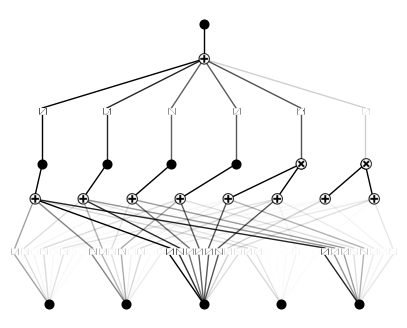

In [ ]:
model = KAN(width=[5, [4, 2], 1], grid=5, k=1, seed=42, device=device)

model(dataset['train_input']);
model.plot()

model = model.fit(dataset, opt="LBFGS", steps=100, lamb=0.0, lamb_entropy=0.0)
model.plot()

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ")

KAN

In [ ]:
model_kan = KAN(width=[5, 3, 1], grid=5, k=1, seed=42, device=device)

model_kan(dataset['train_input']);
model_kan.plot()

model_kan = model_kan.fit(dataset, opt="LBFGS", steps=100, lamb=0.0, lamb_entropy=0.0)
model_kan.plot()

lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)
formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ")